# Notebook 5: Activation Patching
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Kausale Intervention — welche Schichten und Positionen tragen zur richtigen Antwort bei?

> **Aufgabe:** Implementiere die Zellen schrittweise. Dies ist das komplexeste Notebook\!
> 
> Hilfreiche Dokumentation:
> - PyTorch Hooks: https://pytorch.org/docs/stable/generated/torch.nn.Module.register_forward_hook.html
> - PyTorch Tensor clone: https://pytorch.org/docs/stable/generated/torch.Tensor.clone.html
> - Matplotlib Imshow: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html

> **Empfehlung:** Lies zuerst den Hintergrund vollständig durch, bevor du beginnst.

## Hintergrund: Activation Patching — der Gold-Standard

### Das Problem mit Attention und Probing
- **Attention-Analyse**: Zeigt Korrelationen, keine Kausalität
- **Probing**: Zeigt, wo Information kodiert ist — nicht ob sie für die Ausgabe genutzt wird

### Die Idee
Activation Patching führt ein **kontrolliertes Experiment** durch:

```
Clean:     "The capital of France is"  →  P(" Paris") = hoch
Corrupted: "The capital of Xyzzy is"   →  P(" Paris") = niedrig
```

Dann: Korrupten Run wiederholen, aber die Aktivierung einer bestimmten **Schicht L** bei **Position P** mit der sauberen Version ersetzen.

**Wenn der Effekt stark ist** (P(" Paris") steigt nach dem Patchen):  
→ Diese Schicht/Position *enthält* die entscheidende Information

### Der Patching-Effekt
```
Effect(L, P) = logit_patched(" Paris") - logit_corrupt(" Paris")
```

Oder normalisiert:
```
Normalized_Effect(L, P) = (logit_patched - logit_corrupt) / (logit_clean - logit_corrupt)
```
Wert nahe 1.0 = vollständige Wiederherstellung der sauberen Vorhersage

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

# Standard-library imports used only for notebook setup.
import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

# Add the assignment utility directory to the import path.
utils_dir = Path.cwd().parent / "utils"
if not (utils_dir / "config.py").exists():
    raise FileNotFoundError(f"Could not find the assignment utils directory: {utils_dir}")

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Reload utility modules so notebook reruns pick up local code changes.
import config
import model_utils
import plotting_utils
import activation_patching_utils

for module in [config, model_utils, plotting_utils, activation_patching_utils]:
    importlib.reload(module)

from model_utils import load_model_and_tokenizer, setup_environment
from activation_patching_utils import (
    cache_clean_layer_activations,
    patch_layer_position_and_measure,
    plot_activation_patching_results,
    prepare_activation_patching_prompts,
    print_activation_patching_reflection,
    run_activation_patching_grid,
    run_head_level_patching,
    top_activation_patching_points,
)

device = setup_environment()
model, tokenizer = load_model_and_tokenizer(device)
n_layers = model.config.num_hidden_layers

# Display helper for PNG files produced by plotting utilities.
def display_image(png_name):
    image_path = config.OUTPUT_PNG_DIR / png_name
    if not image_path.exists():
        raise FileNotFoundError(f"Expected image was not found: {image_path}")
    display(Image(filename=str(image_path)))


PyTorch-Version : 2.6.0+cu124
Gerät           : cpu


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Modell-Architektur:
GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm

## 2. Clean und Corrupted Prompts

In [4]:
clean_prompt = "The food was delicious and I felt very"
corrupted_prompt = "The food was disgusting and I felt very"
correct_answer = " satisfied"

# Tokenize both prompts, verify equal sequence length, and compare baseline
# probabilities/logits for the correct answer token.
patching_state = prepare_activation_patching_prompts(
    model,
    tokenizer,
    device,
    clean_prompt,
    corrupted_prompt,
    correct_answer,
)
clean_inputs = patching_state["clean_inputs"]
corrupted_inputs = patching_state["corrupted_inputs"]
clean_tokens = patching_state["clean_tokens"]
correct_tok_id = patching_state["correct_tok_id"]
seq_len = patching_state["seq_len"]
clean_logit = patching_state["clean_logit"]
corr_base_logit = patching_state["corrupted_logit"]


Clean tokens:
 0: 'The'
 1: ' food'
 2: ' was'
 3: ' delicious'
 4: ' and'
 5: ' I'
 6: ' felt'
 7: ' very'

Corrupted tokens:
 0: 'The'
 1: ' food'
 2: ' was'
 3: ' disgusting'
 4: ' and'
 5: ' I'
 6: ' felt'
 7: ' very'

Correct answer token: ' satisfied' -> id 10048
P(' satisfied' | clean)     = 0.102341
P(' satisfied' | corrupted) = 0.000136
Probability difference = 0.102205
Clean logit            = 15.784170
Corrupted logit        = 9.207347


## 3. Schritt 1: Clean-Aktivierungen cachen

In [5]:
# Cache the clean hidden state from every transformer layer.
# The utility uses forward hooks and stores detached clones so later corrupted
# runs can safely reuse these activations for intervention.
clean_cache = cache_clean_layer_activations(model, clean_inputs)


Cached clean activations for 24 transformer layers.


## 4. Schritt 2: Patching-Funktion implementieren

In [6]:
# Patch one layer/position pair in the corrupted run and measure the correct-answer logit.
# This quick test verifies that the patching hook is wired correctly before the full grid.
test_logit = patch_layer_position_and_measure(
    model,
    corrupted_inputs,
    clean_cache,
    patch_layer=min(10, n_layers - 1),
    patch_pos=-1,
    correct_tok_id=correct_tok_id,
)
print(f"Test patched logit: {test_logit:.6f}")


Test patched logit: 9.682974


## 5. Schritt 3: Alle Layer × Positionen patchen

In [7]:
# Patch every layer and token position, then normalize the recovery effect.
# Normalized effect: 0 means no recovery, 1 means full recovery of the clean logit.
patching_result = run_activation_patching_grid(
    model,
    patching_state,
    clean_cache,
)
results = patching_result["patched_logits"]
normalized = patching_result["normalized_effects"]


Activation patching layer 24/24


## 6. Heatmap visualisieren

Saved file: activation_patching_heatmap.png


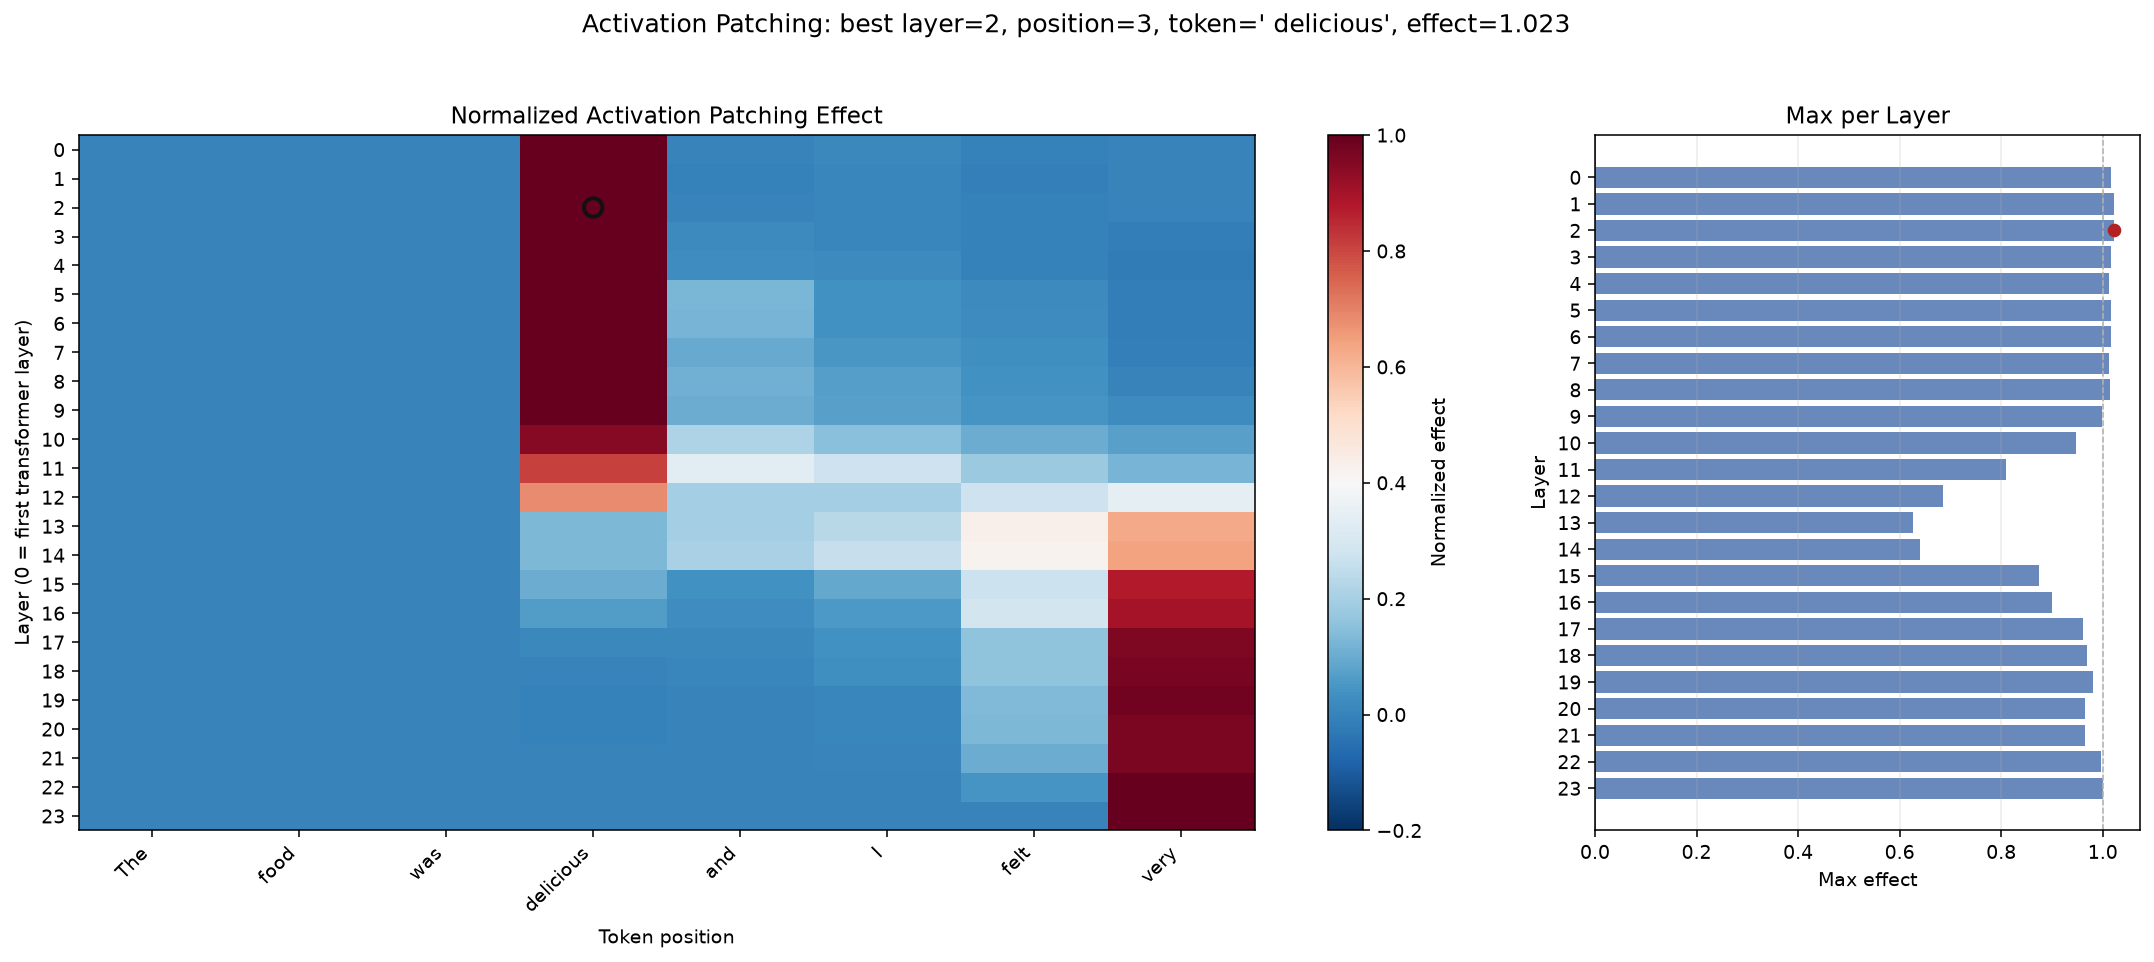

In [8]:
# Save and display the normalized patching heatmap and max-effect-per-layer panel.
activation_patching_plot_path = plot_activation_patching_results(
    patching_result,
    patching_state,
    filename_or_path=config.ACTIVATION_PATCHING_HEATMAP_PATH,
)
display_image(config.ACTIVATION_PATCHING_HEATMAP_PATH.name)


## 7. Top-Patching-Punkte analysieren

In [9]:
# Print the top layer/position combinations ranked by normalized patching effect.
top_patching_points = top_activation_patching_points(
    patching_result,
    patching_state,
    top_k=10,
)


Rank   Layer   Position  Token          Effect
----------------------------------------------------------
1      2       3         ' delicious'   1.022549
2      1       3         ' delicious'   1.021294
3      0       3         ' delicious'   1.016936
4      3       3         ' delicious'   1.016490
5      6       3         ' delicious'   1.015923
6      5       3         ' delicious'   1.015351
7      8       3         ' delicious'   1.014577
8      7       3         ' delicious'   1.013118
9      4       3         ' delicious'   1.011397
10     23      7         ' very'        1.000000

Strongest patch point: layer=2, position=3, token=' delicious', effect=1.022549


## 8. BONUS: Head-Level Patching

Head patching layer 24/24
Saved file: activation_patching_head_heatmap.png


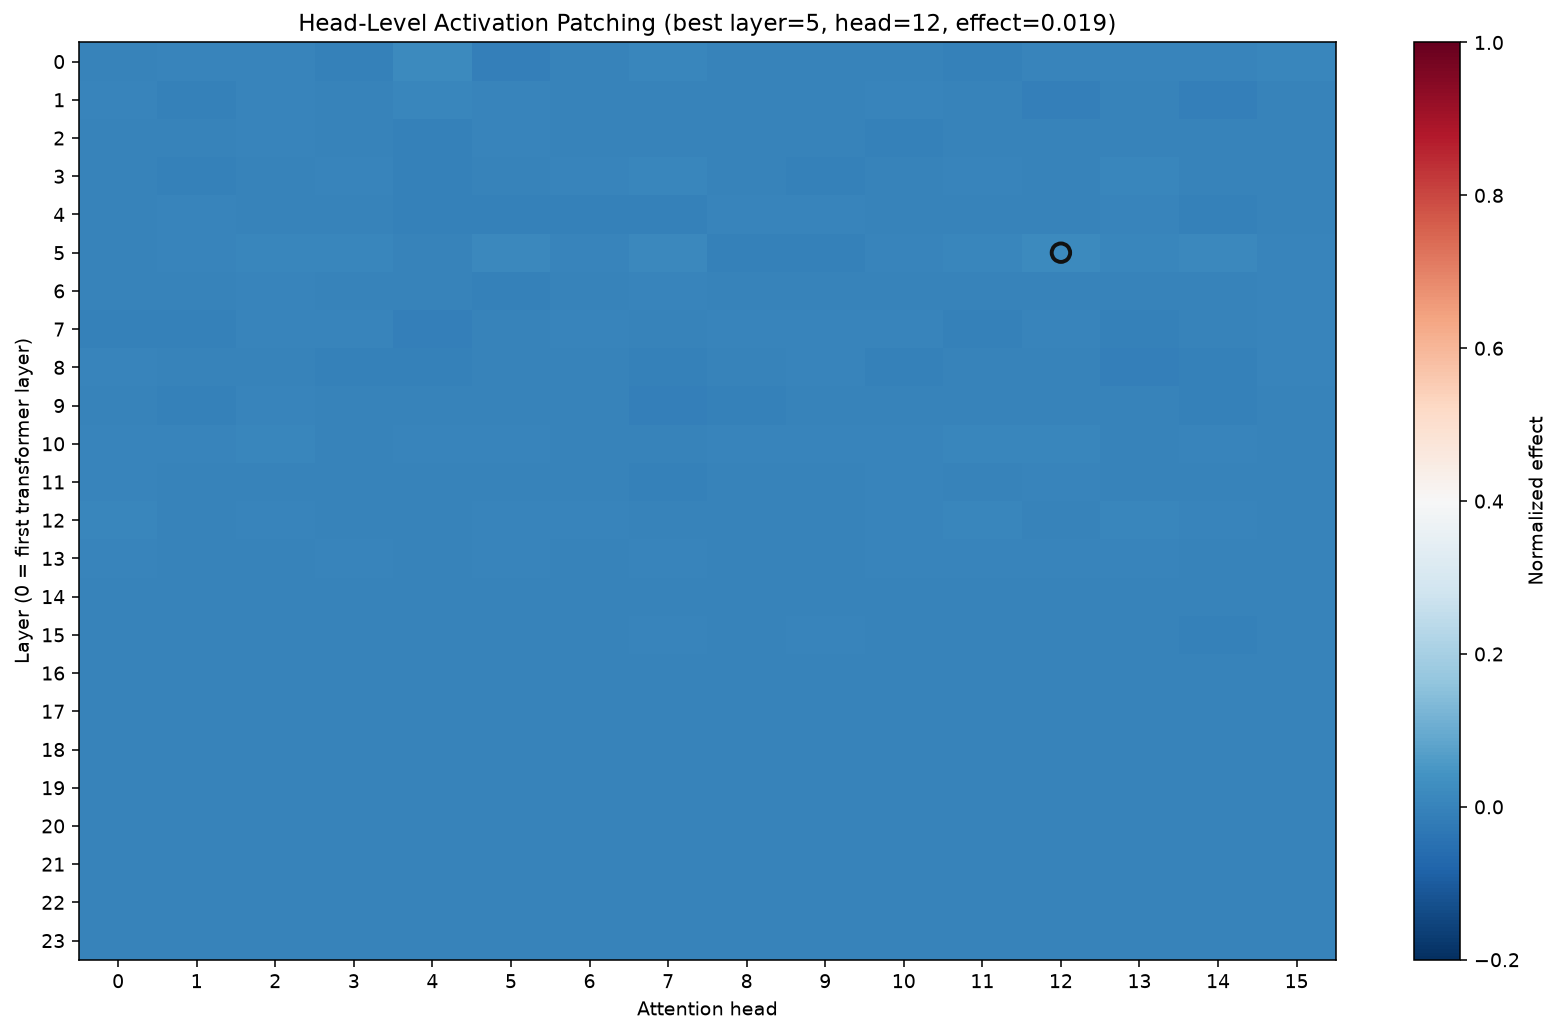

In [10]:
# Optional head-level patching: patch each attention-head slice at the most important
# token position found in the layer/position patching experiment.
head_patching_result = run_head_level_patching(
    model,
    patching_state,
    patch_pos=top_patching_points[0]["position"],
    filename_or_path=config.ACTIVATION_PATCHING_HEAD_HEATMAP_PATH,
)
display_image(config.ACTIVATION_PATCHING_HEAD_HEATMAP_PATH.name)


## 9. Reflexionsfragen

### Antworten auf die Reflexionsfragen

1. Activation Patching ist kausaler als Attention-Analyse, weil es aktiv in den Modelllauf eingreift. Attention zeigt nur, wohin Information fließt; Patching testet, ob eine bestimmte Aktivierung tatsächlich zur Ausgabe beiträgt.

2. Die stärkste Schicht und Position stehen in der Top-10-Tabelle und sind in der Heatmap markiert. Wenn der stärkste Punkt beim Token `France` oder in dessen Nähe liegt, deutet das darauf hin, dass dort entscheidende Information für die Wiederherstellung von `Paris` verarbeitet wird.

3. Probing und Patching messen unterschiedliche Dinge. Probing fragt, ob Information linear dekodierbar ist. Patching fragt, ob diese Information kausal für eine konkrete Vorhersage genutzt wird. Eine Diskrepanz bedeutet, dass Information vorhanden sein kann, ohne direkt ausgaberelevant zu sein.

4. Activation Patching ist rechenintensiv, hängt stark vom gewählten Clean/Corrupted-Prompt-Paar ab und kann durch Superposition schwer interpretierbar werden. Außerdem testet ein Patch immer nur eine konkrete Intervention, nicht automatisch alle möglichen kausalen Pfade.

5. Für Head-Level-Patching patcht man nicht die ganze Schichtaktivierung, sondern nur den Aktivierungsanteil eines einzelnen Attention Heads. Dadurch kann man herausfinden, welche Heads kausal zur Wiederherstellung der korrekten Antwort beitragen.
